# 03 — Evaluate retrieval (baseline vs trained)

For each eval question we embed the query, rank all chunks, and check whether the correct resource is in the top 1 / top 3.

Put the table and plot in your report. Generation still uses a hosted LLM later; **this notebook scores the trained retriever.**

C:\Users\Mwiti\Downloads\AICareerCoach\ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2063.49it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2102.74it/s]

{
  "baseline_recall@1": 1.0,
  "baseline_recall@3": 1.0,
  "trained_recall@1": 1.0,
  "trained_recall@3": 1.0,
  "eval_questions": 8
}


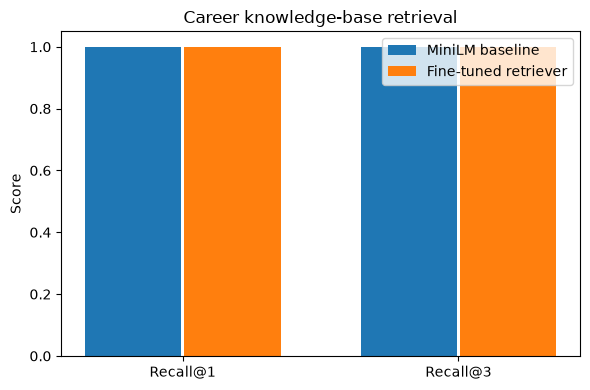

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "src"))
from config import CHUNKS, QA, TRAINED_DIR, METRICS

chunks = json.loads(CHUNKS.read_text(encoding="utf-8"))
eval_df = pd.read_csv(QA).query("split == 'eval'")
corpus = [c["content"] for c in chunks]
resource_ids = [c["resource_id"] for c in chunks]

def recall_at_k(model, k):
    doc_emb = model.encode(corpus, convert_to_numpy=True, normalize_embeddings=True)
    hits = 0
    for row in eval_df.itertuples(index=False):
        q = model.encode([row.query], convert_to_numpy=True, normalize_embeddings=True)[0]
        scores = doc_emb @ q
        top = np.argsort(-scores)[:k]
        retrieved = {resource_ids[i] for i in top}
        if row.resource_id in retrieved:
            hits += 1
    return hits / len(eval_df)

baseline = SentenceTransformer("all-MiniLM-L6-v2")
trained = SentenceTransformer(str(TRAINED_DIR))

results = {
    "baseline_recall@1": recall_at_k(baseline, 1),
    "baseline_recall@3": recall_at_k(baseline, 3),
    "trained_recall@1": recall_at_k(trained, 1),
    "trained_recall@3": recall_at_k(trained, 3),
    "eval_questions": int(len(eval_df)),
}
METRICS.parent.mkdir(parents=True, exist_ok=True)
METRICS.write_text(json.dumps(results, indent=2), encoding="utf-8")
print(json.dumps(results, indent=2))

labels = ["Recall@1", "Recall@3"]
x = np.arange(len(labels))
plt.figure(figsize=(6, 4))
plt.bar(x - 0.18, [results["baseline_recall@1"], results["baseline_recall@3"]], 0.35, label="MiniLM baseline")
plt.bar(x + 0.18, [results["trained_recall@1"], results["trained_recall@3"]], 0.35, label="Fine-tuned retriever")
plt.xticks(x, labels)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Career knowledge-base retrieval")
plt.legend()
plt.tight_layout()
plt.savefig(METRICS.with_suffix(".png"), dpi=140)
plt.show()